In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle
import warnings, os
 
import lightgbm as lgb
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
 
warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)
os.makedirs("data", exist_ok=True)

### LOAD & PREPARE

In [3]:
df = pd.read_parquet("D:/project/Global AI Adoption & Workforce Impact/Data/cleaned.parquet")
df.shape

(150000, 52)

In [4]:
CATEGORICAL = [
    "region", "industry", "company_size",
    "ai_primary_tool", "ai_use_case", "data_privacy_level",
]
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df[CATEGORICAL] = enc.fit_transform(df[CATEGORICAL])

In [5]:
TARGETS = ["revenue_growth_percent", "cost_reduction_percent"]
 
EXCLUDE = [
    "response_id", "company_id", "country",
    "ai_adoption_stage", "adoption_stage_ord",
    "survey_year", "quarter", "time_index",
    "productivity_per_dollar",
    "annual_revenue_usd_millions_w", "num_employees_w", "ai_investment_per_employee_w",
    "roi_proxy",       # direct linear combination of both targets — leaky
] + TARGETS
 
FEATURES = [c for c in df.columns if c not in EXCLUDE]
 
for col in df[FEATURES].select_dtypes(include=["object", "string"]).columns:
    df[col] = OrdinalEncoder(
        handle_unknown="use_encoded_value", unknown_value=-1
    ).fit_transform(df[[col]])
 
X      = df[FEATURES].apply(lambda c: c.cat.codes if hasattr(c, "cat") else c).astype(float)
groups = df["company_id"]
print(f"  Features: {X.shape[1]}   Samples: {len(X):,}")

  Features: 37   Samples: 150,000


### TRAIN ONE MODEL PER TARGET

In [6]:
results = {}
models  = {}
 
for target in TARGETS:
    print(f"\nTraining LightGBM → {target}")
    y = df[target].copy()
 
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=groups))
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
 
    assert len(set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])) == 0
 
    model = lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        min_child_samples=20,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)],
    )
 
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
 
    results[target] = {
        "rmse": rmse, "mae": mae, "r2": r2,
        "y_test": y_test.values, "y_pred": y_pred,
        "best_iter": model.best_iteration_,
    }
    models[target] = model
    print(f"  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}  "
          f"best_iter={model.best_iteration_}")


Training LightGBM → revenue_growth_percent
  RMSE=4.6600  MAE=3.7631  R²=0.2357  best_iter=78

Training LightGBM → cost_reduction_percent
  RMSE=2.9205  MAE=2.3790  R²=0.2445  best_iter=79


### FEATURE IMPORTANCE

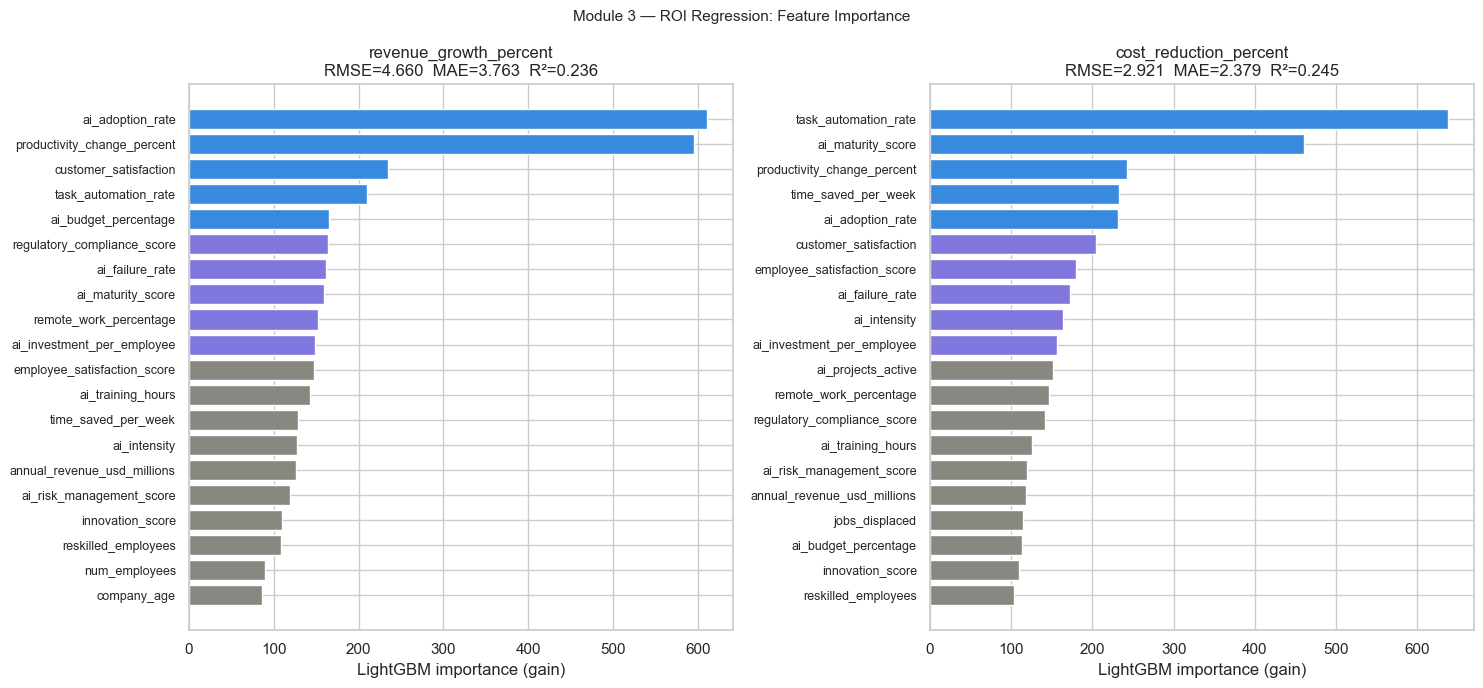

In [7]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
colors = ["#378ADD"] * 5 + ["#7F77DD"] * 5 + ["#888780"] * 10
 
for i, target in enumerate(TARGETS):
    fi = (
        pd.Series(models[target].feature_importances_, index=FEATURES)
        .sort_values(ascending=False)
        .head(20)
    )
    r = results[target]
    axes[i].barh(range(len(fi)), fi.values[::-1], color=colors[::-1])
    axes[i].set_yticks(range(len(fi)))
    axes[i].set_yticklabels(fi.index[::-1], fontsize=9)
    axes[i].set_title(
        f"{target}\nRMSE={r['rmse']:.3f}  MAE={r['mae']:.3f}  R²={r['r2']:.3f}"
    )
    axes[i].set_xlabel("LightGBM importance (gain)")
 
plt.suptitle("Module 3 — ROI Regression: Feature Importance", fontsize=11)
plt.tight_layout()
plt.show()

### ACTUAL VS PREDICTED

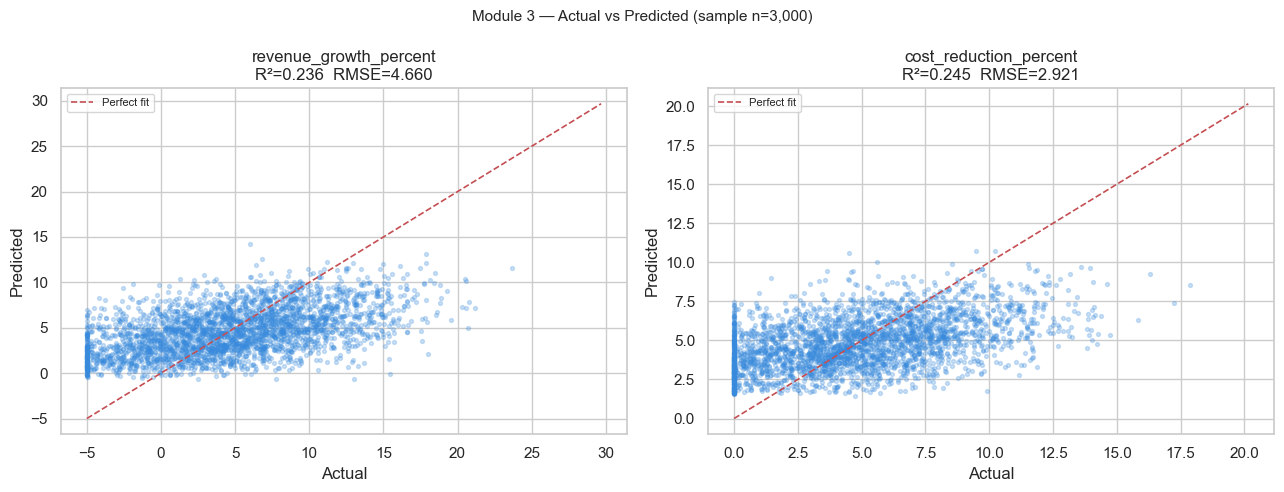

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, target in enumerate(TARGETS):
    r       = results[target]
    yt, yp  = r["y_test"], r["y_pred"]
    idx     = np.random.RandomState(42).choice(len(yt), size=3000, replace=False)
    axes[i].scatter(yt[idx], yp[idx], alpha=0.25, s=8, color="#378ADD")
    lo, hi  = min(yt.min(), yp.min()), max(yt.max(), yp.max())
    axes[i].plot([lo, hi], [lo, hi], "r--", linewidth=1.2, label="Perfect fit")
    axes[i].set_xlabel("Actual"); axes[i].set_ylabel("Predicted")
    axes[i].set_title(f"{target}\nR²={r['r2']:.3f}  RMSE={r['rmse']:.3f}")
    axes[i].legend(fontsize=8)
 
plt.suptitle("Module 3 — Actual vs Predicted (sample n=3,000)", fontsize=11)
plt.tight_layout()
plt.show()

### SHAP BEESWARM — REVENUE MODEL


Computing SHAP values (revenue model, sample=3,000)...


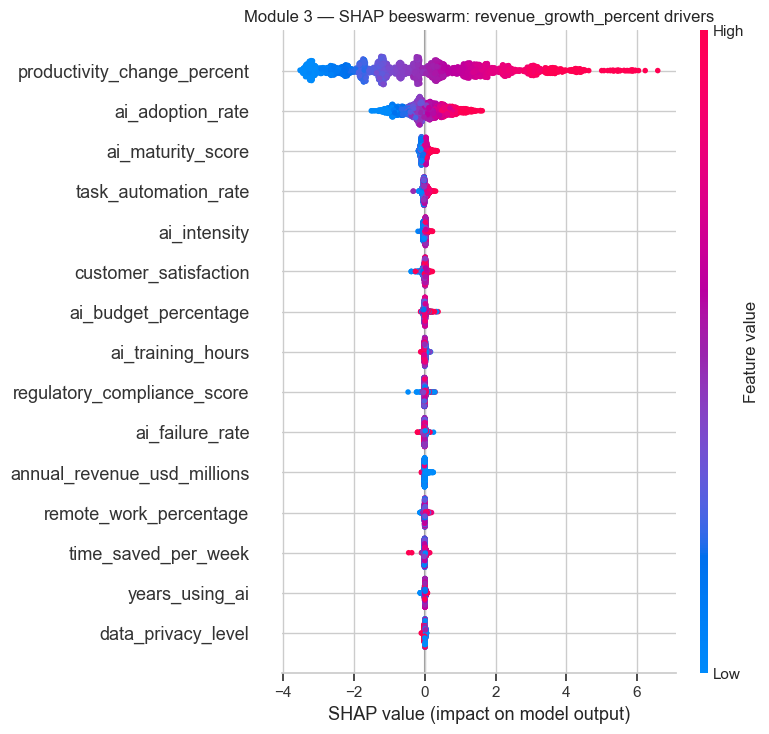

In [9]:
print("\nComputing SHAP values (revenue model, sample=3,000)...")
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
_, test_idx2 = next(gss2.split(X, df["revenue_growth_percent"], groups=groups))
X_test_rev   = X.iloc[test_idx2]
shap_idx     = np.random.RandomState(42).choice(len(X_test_rev), 3000, replace=False)
X_shap       = X_test_rev.iloc[shap_idx]
 
explainer  = shap.TreeExplainer(models["revenue_growth_percent"])
shap_vals  = explainer.shap_values(X_shap)
 
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_vals, X_shap,
    feature_names=FEATURES, max_display=15, show=False,
)
plt.title("Module 3 — SHAP beeswarm: revenue_growth_percent drivers")
plt.tight_layout()
plt.show()

### RESIDUAL PLOTS

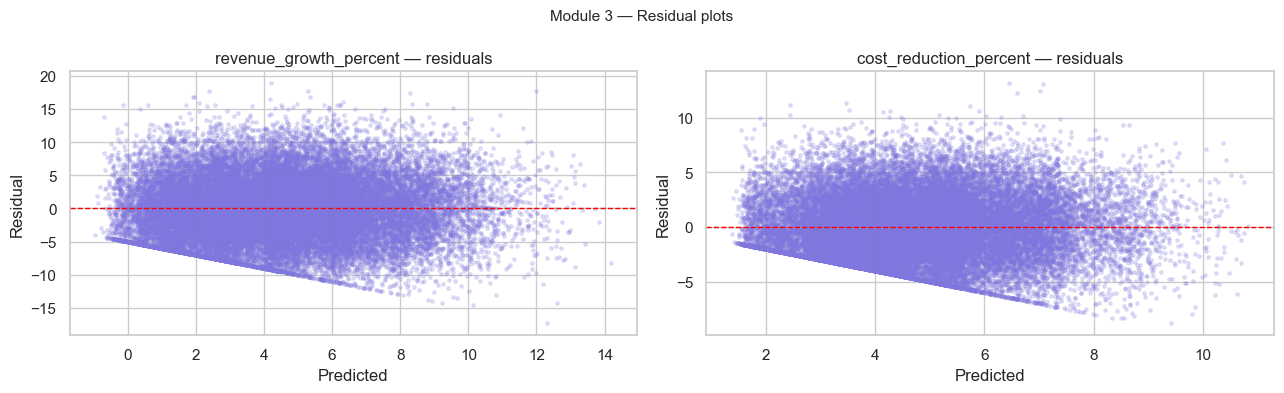

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for i, target in enumerate(TARGETS):
    r     = results[target]
    resid = r["y_test"] - r["y_pred"]
    axes[i].scatter(r["y_pred"], resid, alpha=0.2, s=6, color="#7F77DD")
    axes[i].axhline(0, color="red", linewidth=1, linestyle="--")
    axes[i].set_xlabel("Predicted"); axes[i].set_ylabel("Residual")
    axes[i].set_title(f"{target} — residuals")
 
plt.suptitle("Module 3 — Residual plots", fontsize=11)
plt.tight_layout()
plt.show()